In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [9]:
df = pd.read_csv("mymoviedb (1).csv")

In [10]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [20]:
df.shape

(9837, 9)

Dataset contains 9837 rows and 9 columns.

In [21]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [23]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [24]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df = df.drop_duplicates()

In [27]:
df['Release_Date'].head()

0    15-12-2021
1    01-03-2022
2    25-02-2022
3    24-11-2021
4    22-12-2021
Name: Release_Date, dtype: object

In [30]:
df['Release_Date'] = pd.to_datetime(
    df['Release_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)                                   

In [31]:
df['Release_Date'].isnull().sum()

np.int64(10)

In [32]:
df = df.dropna(subset=['Release_Date'])

In [33]:
df.shape

(9827, 9)

In [34]:
df['Year']=df['Release_Date'].dt.year

In [35]:
df[['Release_Date','Year']].head()

,Release_Date,Year
0,2021-12-15,2021
1,2022-03-01,2022
2,2022-02-25,2022
3,2021-11-24,2021
4,2021-12-22,2021


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9827 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   object        
 5   Vote_Average       9826 non-null   object        
 6   Original_Language  9826 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
 9   Year               9827 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(7)
memory usage: 806.1+ KB


In [37]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           1
Vote_Average         1
Original_Language    1
Genre                1
Poster_Url           1
Year                 0
dtype: int64

In [38]:
df = df.dropna()

In [39]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
Year                 0
dtype: int64

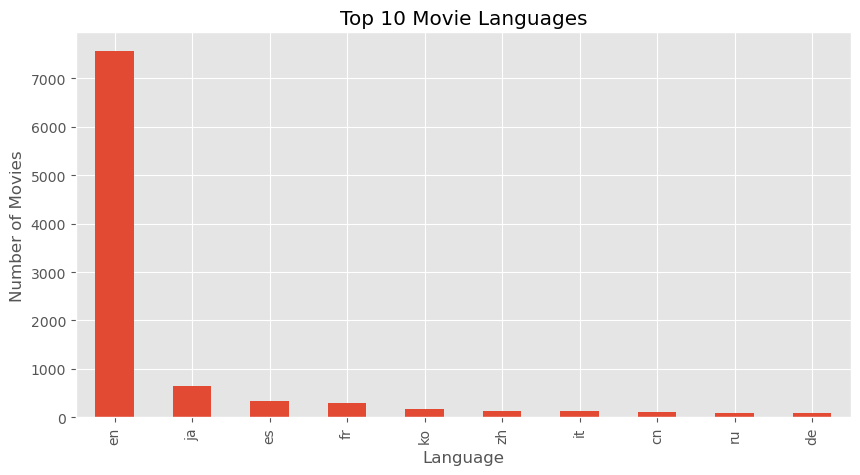

In [40]:
plt.figure(figsize=(10,5))

df['Original_Language'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Movie Languages")
plt.xlabel("Language")
plt.ylabel("Number of Movies")

plt.show()

English is the most common movie language.

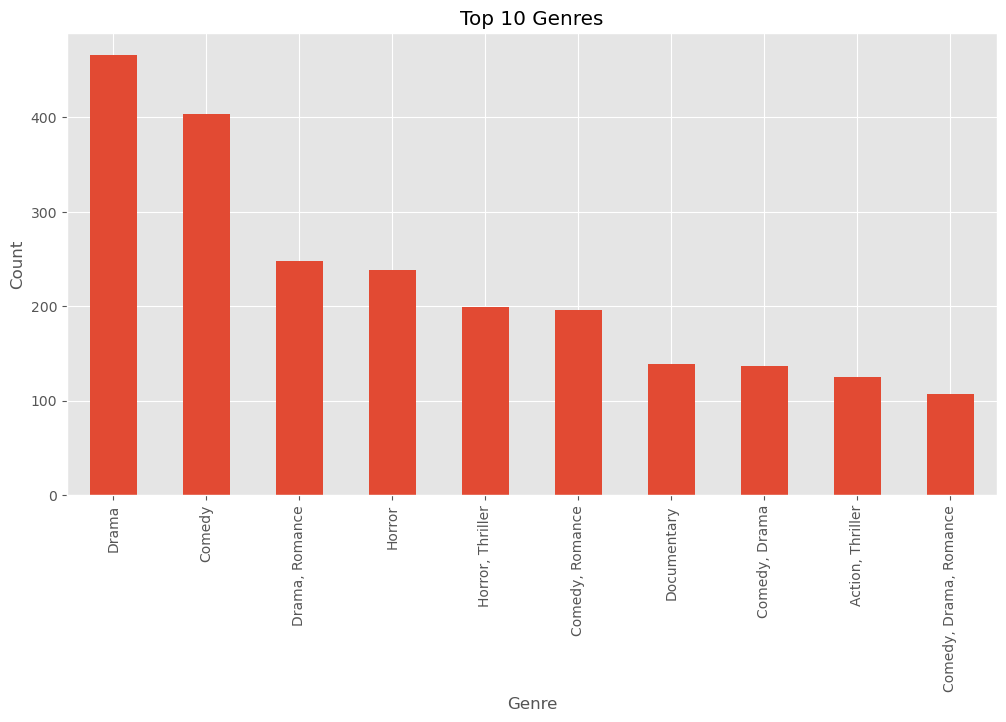

In [41]:
plt.figure(figsize=(12,6))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

Drama is the top genre in the movie industry.

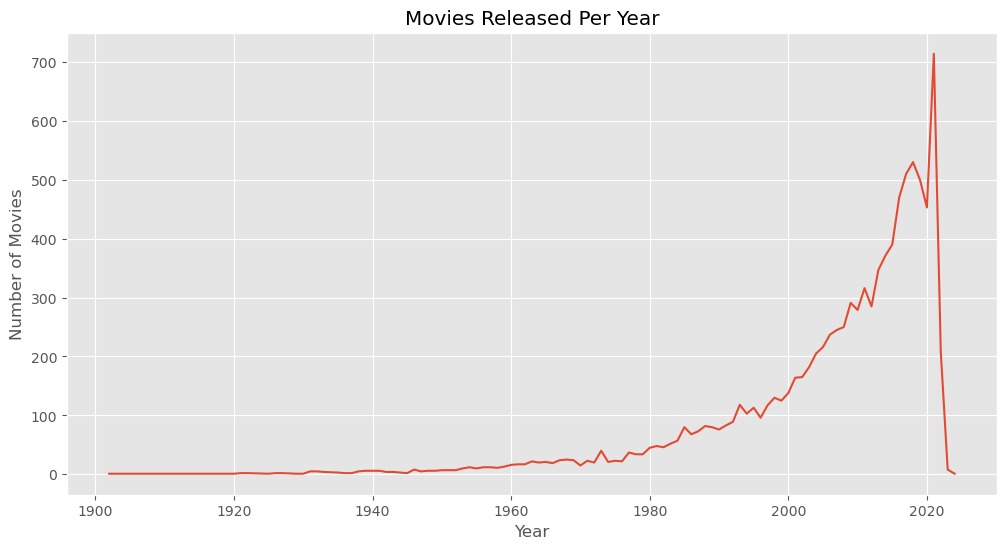

In [42]:
movies_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

movies_per_year.plot()

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

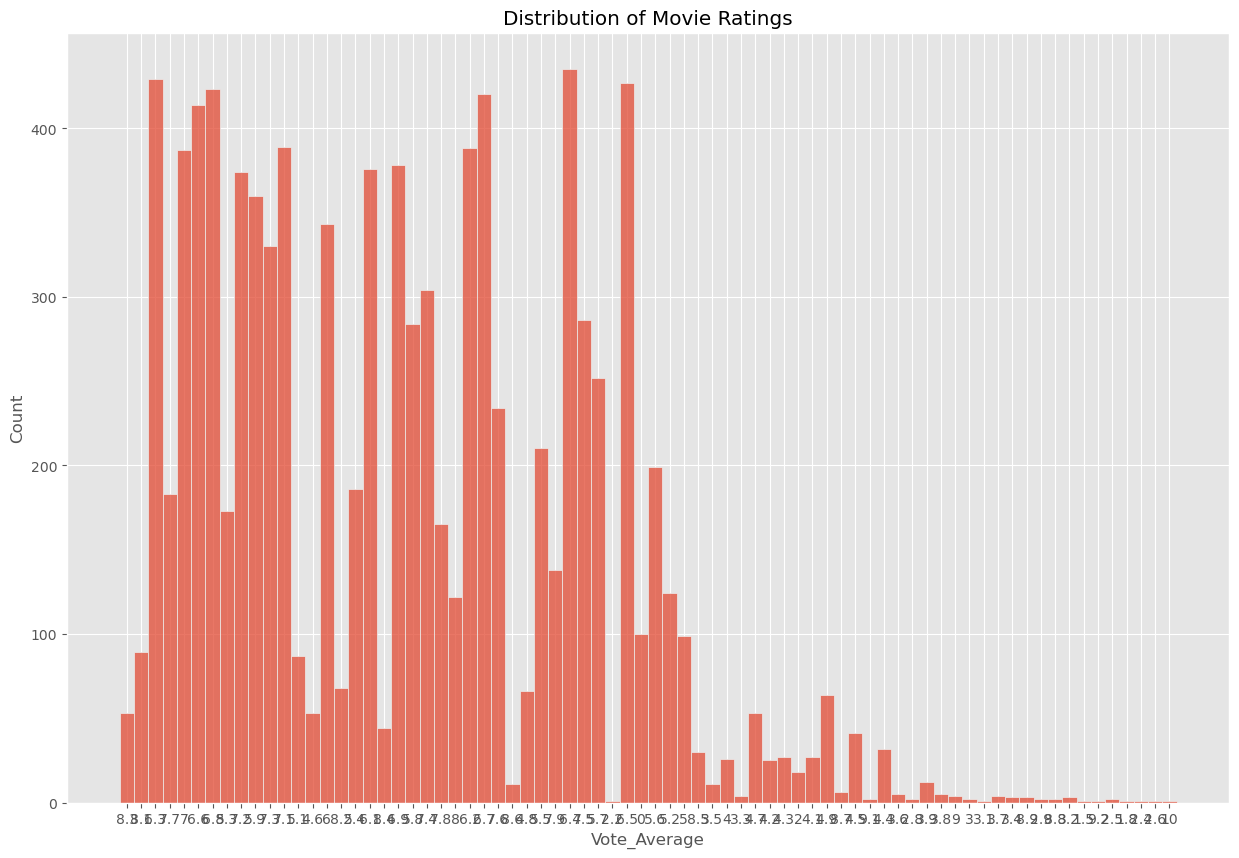

In [46]:
plt.figure(figsize=(15,10))

sns.histplot(df['Vote_Average'], bins=20)
plt.title("Distribution of Movie Ratings")

plt.show()

Most movies have ratings between 6 and 8

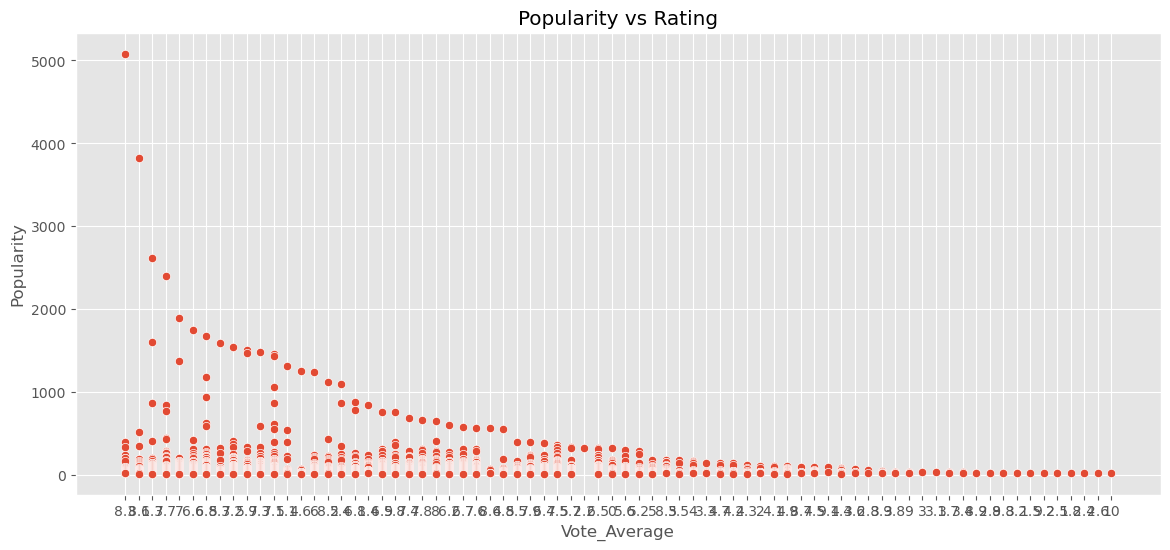

In [53]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    x='Vote_Average',
    y='Popularity',
    data=df
)

plt.title("Popularity vs Rating")

plt.show()

In [54]:
top_movies = df[['Title','Popularity']].sort_values(
    by='Popularity',
    ascending=False
).head(10)

top_movies

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


In [55]:
top_rated = df[['Title','Vote_Average']].sort_values(
    by='Vote_Average',
    ascending=False
).head(10)

top_rated

,Title,Vote_Average
7349,Franco Escamilla: Por La Anécdota,9.2
2335,Impossible Things,9.1
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
7024,Sex School: Dorms of Desire,9
2401,The Three Deaths of Marisela Escobedo,9
6738,Mission «Sky»,9
7411,My Sex Doll,9
7049,Bring the Soul: The Movie,8.9
8657,Burn the Stage: The Movie,8.9
5079,"Ni tuyo, Ni mía",8.9


## Findings

1) The dataset contains 9837 movies and 9 columns.
2) English is the most frequently used language.
3) Certain genres dominate the movie industry.
4) Most movies have ratings between 6 and 8.
5) Movie releases increased significantly in recent years.
6) Higher-rated movies tend to have better popularity.
7) Some movies receive exceptionally high popularity scores.